In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as npr
import pandas as pd

In [3]:
#Load Data
df=pd.read_excel('Bursa Malaysia Listing 3.0.xls', sheet_name='Screening')
df.head()

,Company Name,Total Revenue 2016,Total Revenue 2017,Total Revenue 2018,Total Revenue 2019,Total Revenue 2020,Total Revenue 2021,Net Income 2016,Net Income 2017,Net Income 2018,...,Accounts Receivable 2019,Accounts Receivable 2020,Accounts Receivable 2021,PPE 2016,PPE 2017,PPE 2018,PPE 2019,PPE 2020,PPE 2021,Primary Sector
0,3REN Berhad (KLSE:3REN),-,-,-,-,15.7,17.8,-,-,-,...,-,4.22,4.73,-,-,-,-,0.838,2.19,Information Technology
1,7-Eleven Malaysia Holdings Berhad (KLSE:SEM),469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
2,99 Speed Mart Retail Holdings Berhad (KLSE:99S...,-,-,-,-,1702.3,1880.9,-,-,-,...,-,4.66,4.15,-,-,-,-,286.2,271.6,Consumer Staples
3,A-Rank Berhad (KLSE:ARANK),101.5,123.5,119.6,118.2,109.7,161.3,3.87,3.55,3.22,...,10.3,13.2,16.6,12.3,14.7,13.3,12.6,12.1,12.9,Materials
4,ABF Malaysia Bond Index Fund (KLSE:ABFMY1),-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,Financials


In [4]:
#Standardize company name format
df['Company Name'] = df['Company Name'].str.replace(r"\s*\(.*?\)", "", regex=True)
df.head()

,Company Name,Total Revenue 2016,Total Revenue 2017,Total Revenue 2018,Total Revenue 2019,Total Revenue 2020,Total Revenue 2021,Net Income 2016,Net Income 2017,Net Income 2018,...,Accounts Receivable 2019,Accounts Receivable 2020,Accounts Receivable 2021,PPE 2016,PPE 2017,PPE 2018,PPE 2019,PPE 2020,PPE 2021,Primary Sector
0,3REN Berhad,-,-,-,-,15.7,17.8,-,-,-,...,-,4.22,4.73,-,-,-,-,0.838,2.19,Information Technology
1,7-Eleven Malaysia Holdings Berhad,469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
2,99 Speed Mart Retail Holdings Berhad,-,-,-,-,1702.3,1880.9,-,-,-,...,-,4.66,4.15,-,-,-,-,286.2,271.6,Consumer Staples
3,A-Rank Berhad,101.5,123.5,119.6,118.2,109.7,161.3,3.87,3.55,3.22,...,10.3,13.2,16.6,12.3,14.7,13.3,12.6,12.1,12.9,Materials
4,ABF Malaysia Bond Index Fund,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,Financials


In [5]:
#Sum of null cases
df.apply(lambda x: sum(x.isnull()), axis=0)

Company Name                1
Total Revenue 2016          2
Total Revenue 2017          2
Total Revenue 2018          2
Total Revenue 2019          2
Total Revenue 2020          2
Total Revenue 2021          2
Net Income 2016             2
Net Income 2017             2
Net Income 2018             2
Net Income 2019             2
Net Income 2020             2
Net Income 2021             2
Cash from Ops 2016          2
Cash from Ops 2017          2
Cash from Ops 2018          2
Cash from Ops 2019          2
Cash from Ops 2020          2
Cash from Ops 2021          2
Total Assets 2016           2
Total Assets 2017           2
Total Assets 2018           2
Total Assets 2019           2
Total Assets 2020           2
Total Assets 2021           2
Accounts Receivable 2016    2
Accounts Receivable 2017    2
Accounts Receivable 2018    2
Accounts Receivable 2019    2
Accounts Receivable 2020    2
Accounts Receivable 2021    2
PPE 2016                    2
PPE 2017                    2
PPE 2018  

In [6]:
#Drop row with null and missing value
df1 = df.copy()
df1.dropna(axis=0, inplace=True)
df1 = df1[~df.iloc[:, 2:-1].apply(lambda x: x.astype(str).str.contains('-')).any(axis=1)]

C:\Users\hp\AppData\Local\Temp\ipykernel_3948\3989605822.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1 = df1[~df.iloc[:, 2:-1].apply(lambda x: x.astype(str).str.contains('-')).any(axis=1)]


In [7]:
df1.head()

,Company Name,Total Revenue 2016,Total Revenue 2017,Total Revenue 2018,Total Revenue 2019,Total Revenue 2020,Total Revenue 2021,Net Income 2016,Net Income 2017,Net Income 2018,...,Accounts Receivable 2019,Accounts Receivable 2020,Accounts Receivable 2021,PPE 2016,PPE 2017,PPE 2018,PPE 2019,PPE 2020,PPE 2021,Primary Sector
1,7-Eleven Malaysia Holdings Berhad,469,537.8,536.1,576.6,631.8,674.1,11.6,12.3,12.4,...,0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples
12,Advancecon Holdings Berhad,52.3,65.4,66,73.8,62.3,65,5.9,4.54,2.57,...,40.1,43.7,35.6,30.4,45.3,46,43.7,40.9,35.3,Industrials
16,Aeon Co. Bhd.,900.6,1014,1052.7,1108.4,1008.1,871.3,17.8,25.8,25.4,...,11.4,20,22.5,771.7,861.7,894.6,1323.5,1258.2,1106.3,Consumer Staples
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.1,46.9,14.4,...,10.5,10.1,11.9,18.5,21.3,18.6,38.5,72.3,98.5,Consumer Staples
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,...,22.1,19.1,17.9,40.8,42.8,38,36.4,38.2,34.3,Industrials


In [8]:
#Check
df1.apply(lambda x: sum(x.isnull()), axis=0)

Company Name                0
Total Revenue 2016          0
Total Revenue 2017          0
Total Revenue 2018          0
Total Revenue 2019          0
Total Revenue 2020          0
Total Revenue 2021          0
Net Income 2016             0
Net Income 2017             0
Net Income 2018             0
Net Income 2019             0
Net Income 2020             0
Net Income 2021             0
Cash from Ops 2016          0
Cash from Ops 2017          0
Cash from Ops 2018          0
Cash from Ops 2019          0
Cash from Ops 2020          0
Cash from Ops 2021          0
Total Assets 2016           0
Total Assets 2017           0
Total Assets 2018           0
Total Assets 2019           0
Total Assets 2020           0
Total Assets 2021           0
Accounts Receivable 2016    0
Accounts Receivable 2017    0
Accounts Receivable 2018    0
Accounts Receivable 2019    0
Accounts Receivable 2020    0
Accounts Receivable 2021    0
PPE 2016                    0
PPE 2017                    0
PPE 2018  

In [9]:
#Standardize column name
df1.columns = (
    df1.columns
    .str.replace('Net Income ', 'NI_')
    .str.replace('Cash from Ops ', 'OCF_')
    .str.replace('Accounts Receivable ', 'AR_')
    .str.replace('Total Assets ', 'TA_')
    .str.replace('Total Revenue ', 'REV_')
    .str.replace('PPE ', 'PPE_')
)

In [10]:
col_dtype = ['REV_2016', 'REV_2017', 'REV_2018', 'REV_2019',
       'REV_2020', 'REV_2021', 'NI_2016', 'NI_2017', 'NI_2018', 'NI_2019',
       'NI_2020', 'NI_2021', 'OCF_2016', 'OCF_2017', 'OCF_2018', 'OCF_2019',
       'OCF_2020', 'OCF_2021', 'TA_2016', 'TA_2017', 'TA_2018', 'TA_2019',
       'TA_2020', 'TA_2021', 'AR_2016', 'AR_2017', 'AR_2018', 'AR_2019',
       'AR_2020', 'AR_2021', 'PPE_2016', 'PPE_2017', 'PPE_2018', 'PPE_2019',
       'PPE_2020', 'PPE_2021']

# Replace parentheses with negative sign for negative values
df1[col_dtype] = df1[col_dtype].replace({r'\((.*?)\)': r'-\1'}, regex=True)

#Convert data type of Numerical Data to Float
df1[col_dtype] = df1[col_dtype].astype(float)
df1.dtypes

Company Name       object
REV_2016          float64
REV_2017          float64
REV_2018          float64
REV_2019          float64
REV_2020          float64
REV_2021          float64
NI_2016           float64
NI_2017           float64
NI_2018           float64
NI_2019           float64
NI_2020           float64
NI_2021           float64
OCF_2016          float64
OCF_2017          float64
OCF_2018          float64
OCF_2019          float64
OCF_2020          float64
OCF_2021          float64
TA_2016           float64
TA_2017           float64
TA_2018           float64
TA_2019           float64
TA_2020           float64
TA_2021           float64
AR_2016           float64
AR_2017           float64
AR_2018           float64
AR_2019           float64
AR_2020           float64
AR_2021           float64
PPE_2016          float64
PPE_2017          float64
PPE_2018          float64
PPE_2019          float64
PPE_2020          float64
PPE_2021          float64
Primary Sector     object
dtype: objec

In [11]:
import pandas as pd

# Example for REV: select all REV_* columns and stack into one long Series
rev_all = df1.filter(like='REV_').stack().reset_index(drop=True)
ocf_all = df1.filter(like='OCF_').stack().reset_index(drop=True)
ni_all  = df1.filter(like='NI_').stack().reset_index(drop=True)
ppe_all = df1.filter(like='PPE_').stack().reset_index(drop=True)
ta_all  = df1.filter(like='TA_').stack().reset_index(drop=True)
ar_all  = df1.filter(like='AR_').stack().reset_index(drop=True)

# Create a new DataFrame
df1_summary = pd.DataFrame({
    'REV': rev_all,
    'OCF': ocf_all,
    'NI': ni_all,
    'PPE': ppe_all,
    'TA': ta_all,
    'AR': ar_all
})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
# Get descriptive statistics
df1_descriptive = df1_summary.describe().T.round(2)
print(df1_descriptive)

      count     mean      std   min    25%     50%     75%      max
REV  1122.0   520.41  1329.48  1.94  40.40  101.20  373.02  12631.6
OCF  1122.0    98.32   312.65  0.00   4.99   13.85   66.75   4751.6
NI   1122.0    57.68   155.04  0.01   3.79   10.85   46.68   1934.6
PPE  1122.0   499.97  2375.50  0.25  16.00   42.55  300.82  36703.1
TA   1122.0  1059.97  3327.94  4.85  61.50  150.00  748.78  45146.1
AR   1122.0    76.92   200.91  0.00   4.88   13.70   63.22   2627.2


In [12]:
df1_descriptive.to_excel("df1_describe_output.xlsx")

#Data labeling (Modified Jones Model)

In [13]:
from sklearn.linear_model import LinearRegression

#Function for DA calculation
def data_label(data, start_year=2017, end_year=2021):
    result = data.copy()
    
    # Step 1: Calculate Total Accruals
    for year in range(start_year, end_year + 1):
        result[f'TAC_{year}'] = result[f'NI_{year}'] - result[f'OCF_{year}']
        result[f'dREV_{year}'] = result[f'REV_{year}'] - result[f'REV_{year - 1}']
        result[f'dAR_{year}'] = result[f'AR_{year}'] - result[f'AR_{year - 1}']

    # Step 2: Calculate DA for each year using MJM regression
    for year in range(start_year, end_year + 1):
        try:
            temp = result.copy()

            # independent variables
            temp['X1'] = 1 / temp[f'TA_{year - 1}']
            temp['X2'] = (temp[f'dREV_{year}'] - temp[f'dAR_{year}']) / temp[f'TA_{year - 1}']
            temp['X3'] = temp[f'PPE_{year}'] / temp[f'TA_{year - 1}']

            # dependent variable
            temp['Y'] = temp[f'TAC_{year}'] / temp[f'TA_{year - 1}']

            # Fit regression
            model = LinearRegression()
            X = temp[['X1', 'X2', 'X3']]
            y = temp['Y']
            model.fit(X, y)

            # Predict NDAC and calculate DA
            result.loc[temp.index, f'NDAC_{year}'] = model.predict(X)
            result.loc[temp.index, f'DA_{year}'] = result.loc[temp.index, f'TAC_{year}'] / result.loc[temp.index, f'TA_{year - 1}'] - result.loc[temp.index, f'NDAC_{year}']

        except Exception as e:
            print(f"Error calculating DA for {year}: {e}")

    return result

In [14]:
final_df = data_label(df1)
final_df

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,NI_2019,NI_2020,NI_2021,OCF_2016,OCF_2017,OCF_2018,OCF_2019,OCF_2020,OCF_2021,TA_2016,TA_2017,TA_2018,TA_2019,TA_2020,TA_2021,AR_2016,AR_2017,AR_2018,AR_2019,AR_2020,AR_2021,PPE_2016,PPE_2017,PPE_2018,PPE_2019,PPE_2020,PPE_2021,Primary Sector,TAC_2017,dREV_2017,dAR_2017,TAC_2018,dREV_2018,dAR_2018,TAC_2019,dREV_2019,dAR_2019,TAC_2020,dREV_2020,dAR_2020,TAC_2021,dREV_2021,dAR_2021,NDAC_2017,DA_2017,NDAC_2018,DA_2018,NDAC_2019,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,13.20,7.410,10.600,16.300,12.100,19.90,75.70,58.800,63.10,172.5,195.5,181.2,347.3,506.8,543.1,1.06,1.37,1.54,0.00,0.152,0.318,71.10,86.20,78.30,231.20,253.60,233.7,Consumer Staples,0.200,68.8,0.31,-7.50,-1.7,0.17,-62.50,40.5,-1.54,-51.390,55.2,0.152,-52.500,42.3,0.166,-0.008798,0.009958,-0.019658,-0.018705,-0.109796,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,2.64,0.523,0.492,5.190,5.000,3.36,3.08,4.950,6.01,66.0,90.7,99.5,100.1,101.5,106.1,27.40,30.30,35.50,40.10,43.700,35.600,30.40,45.30,46.00,43.70,40.90,35.3,Industrials,-0.460,13.1,2.90,-0.79,0.6,5.20,-0.44,7.8,4.60,-4.427,-11.5,3.600,-5.518,2.7,-8.100,-0.025507,0.018538,-0.015771,0.007061,-0.050266,0.045844,-0.032561,-0.011664,-0.020884,-0.033480
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,26.70,10.300,20.500,103.800,94.700,136.30,168.30,98.600,167.70,985.1,1084.4,1123.6,1596.5,1516.2,1407.1,11.70,18.70,13.60,11.40,20.000,22.500,771.70,861.70,894.60,1323.50,1258.20,1106.3,Consumer Staples,-68.900,113.4,7.00,-110.90,38.7,-5.10,-141.60,55.7,-2.20,-88.300,-100.3,8.600,-147.200,-136.8,2.500,-0.042250,-0.027692,-0.037102,-0.065167,-0.088560,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,13.60,14.000,9.680,8.460,21.100,13.50,20.00,15.600,5.18,85.4,117.6,122.6,132.8,159.3,172.1,9.89,9.45,10.70,10.50,10.100,11.900,18.50,21.30,18.60,38.50,72.30,98.5,Consumer Staples,25.800,14.7,-0.44,0.90,-0.1,1.25,-6.40,5.2,-0.20,-1.600,-1.8,-0.400,4.500,4.3,1.800,-0.006223,0.308331,-0.013342,0.020995,-0.046189,-0.006013,-0.044258,0.032210,-0.031530,0.059779
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,1.21,0.293,4.160,7.710,4.590,5.57,2.87,7.580,3.79,104.3,114.5,114.6,114.4,114.3,116.4,26.40,27.00,24.60,22.10,19.100,17.900,40.80,42.80,38.00,36.40,38.20,34.3,Industrials,-1.250,2.2,0.60,0.31,0.7,-2.40,-1.66,-13.6,-2.50,-7.287,-15.2,-3.000,0.370,1.2,-1.200,-0.022527,0.010543,-0.022831,0.025538,-0.032196,0.017711,-0.032039,-0.031659,-0.018837,0.022074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,Westports Holdings Berhad,453.8,513.6,390.4,435.4,491.4,485.3,142.00,160.20,129.00,144.30,162.900,194.000,196.800,266.900,142.10,234.40,255.000,264.20,969.8,1265.5,1230.2,1253.3,1309.3,1299.7,60.50,60.90,69.30,66.80,65.700,58.400,337.90,449.80,429.60,418.90,418.30,430.6,Industrials,-106.700,59.8,0.40,-13.10,-123.2,8.40,-90.10,45.0,-2.50,-92.100,56.0,-1.100,-70.200,-6.1,-7.300,-0.026197,-0.083826,-0.005375,-0.004977,-0.048793,-0.024447,-0.040071,-0.033415,-0.022731,-0.030885
1044,Willowglen MSC Berhad,29.4,38.2,32.6,34.0,36.4,41.1,4.08,4.60,2.69,3.63,4.450,3.660,0.772,0.882,10.70,4.90,0.759,2.48,35.1,44.1,43.6,48.3,52.6,51.3,18.20,24.80,16.10,16.50,21.500,21.900,2.58,3.85,3.65,4.36,3.97,3.3,Information Technology,3.718,8.8,6.60,-8.01,-5.6,-8.70,-1.27,1.4,0.40,3.691,2.4,5.000,1.180,4.7,0.400,0.001293,0.104633,-0.021629,-0.160004,-0.030372,0.001244,-0.023701,0.100119,-0.006679,0.029112
1058,Y.S.P. Southeast Asia Holding Berhad,52.9,64.3,69.8,72.2,73.9,67.6,

#Descriptive Stats of DA

In [15]:
# Stack all DA values into a single Series (ignoring NaNs by default)
all_da_values = final_df[da_columns].stack().reset_index(drop=True)

# Compute descriptive stats with 4 decimal places
combined_stats = all_da_values.describe().round(4)

print(combined_stats)

count    935.0000
mean      -0.0000
std        0.0595
min       -0.3392
25%       -0.0296
50%        0.0036
75%        0.0328
max        0.3083
dtype: float64


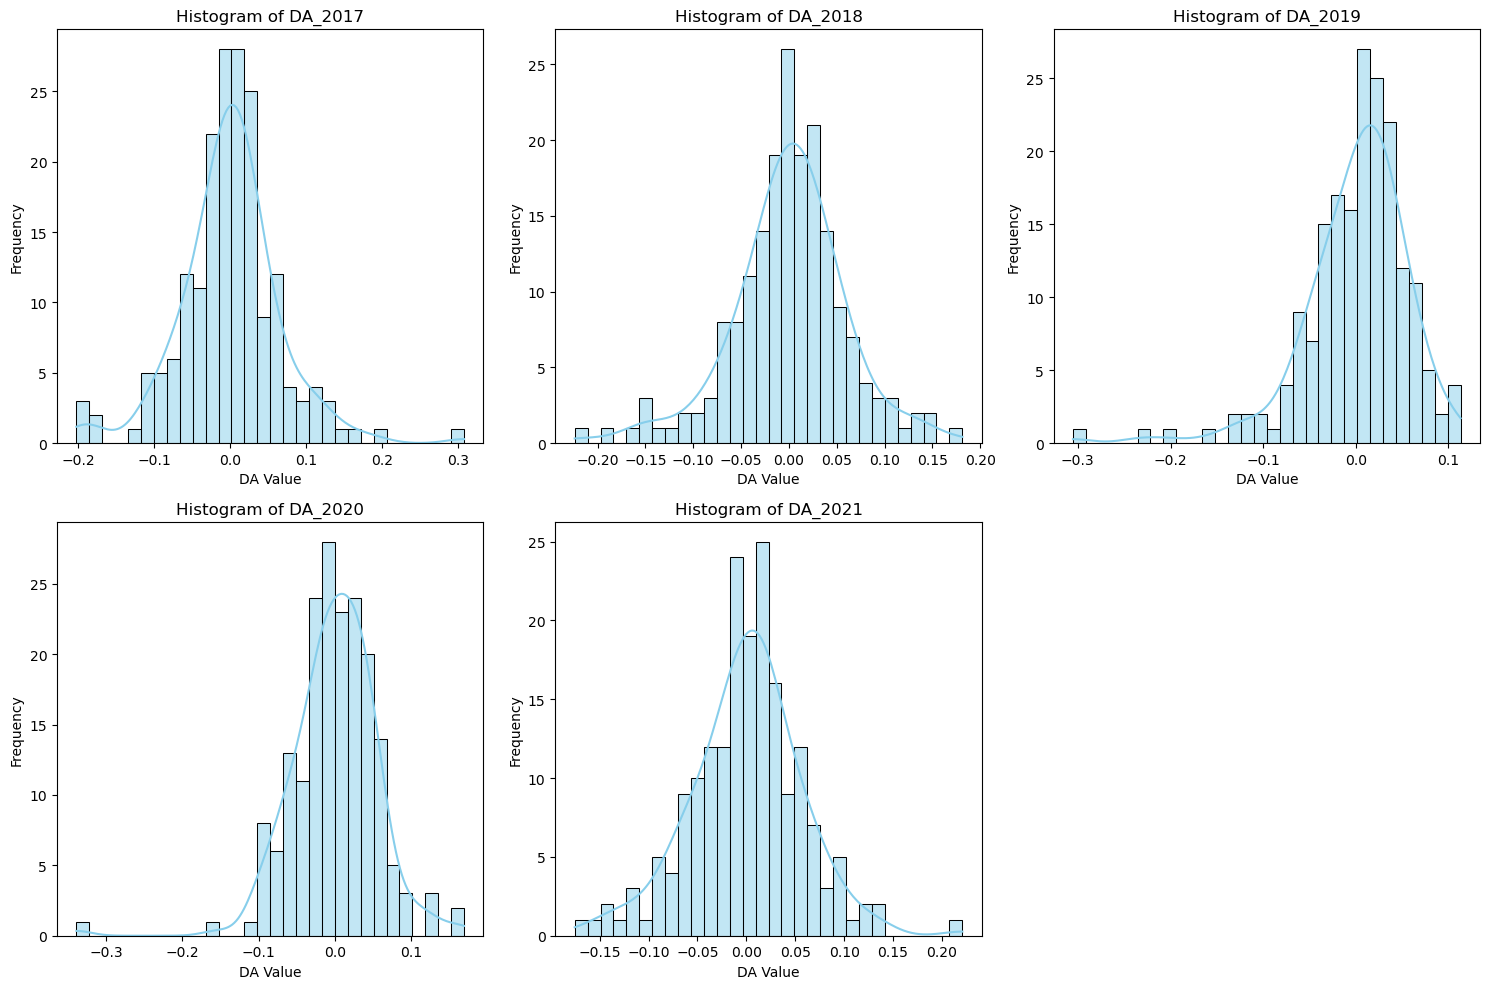

In [16]:
import seaborn as sns

#Histogram of DA
da_columns = ['DA_2017', 'DA_2018', 'DA_2019', 'DA_2020','DA_2021']
plt.figure(figsize=(15, 10))

for i, col in enumerate(da_columns, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns of subplots
    sns.histplot(final_df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel('DA Value')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

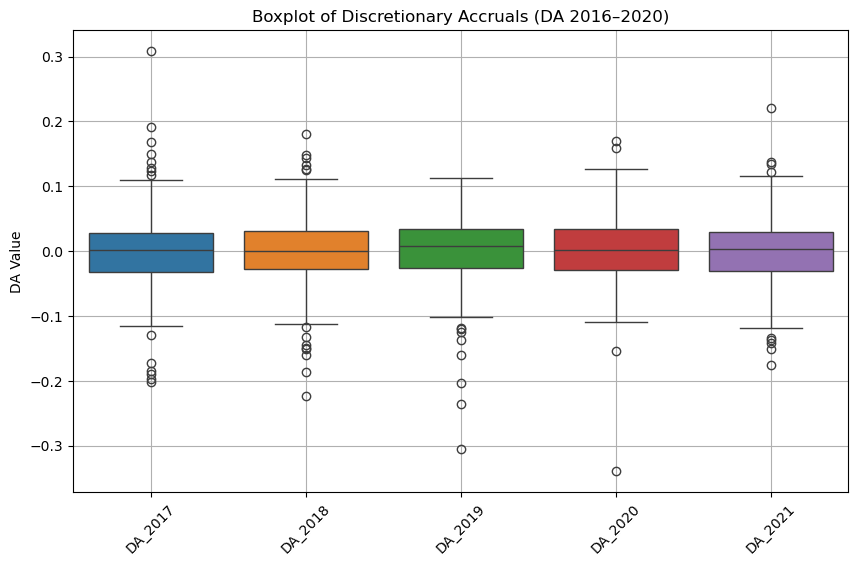

In [17]:
#box plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=final_df[da_columns])
plt.title('Boxplot of Discretionary Accruals (DA 2016–2020)')
plt.ylabel('DA Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [18]:
def classify_em_global(df, da_columns, lower_q=0.25, upper_q=0.75):
    all_da_values = pd.concat([df[col] for col in da_columns], ignore_index=True)
    q_low = all_da_values.quantile(lower_q)
    q_high = all_da_values.quantile(upper_q)

    # Step 2: Classify each column based on global thresholds
    for col in da_columns:
        df[f'{col}_Classification'] = np.select(
            [
                df[col] < q_low,   # Downward manipulation
                df[col] > q_high   # Upward manipulation
            ],
            [1, 2],               # 1 = downward EM, 2 = upward EM
            default=0             # 0 = normal
        )

    return df

In [19]:
da_columns = ['DA_2017', 'DA_2018', 'DA_2019', 'DA_2020', 'DA_2021']
final_df = classify_em_global(final_df, da_columns, lower_q=0.25, upper_q=0.75)

In [20]:
final_df.head()

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,NI_2019,NI_2020,NI_2021,OCF_2016,OCF_2017,OCF_2018,OCF_2019,OCF_2020,OCF_2021,TA_2016,TA_2017,TA_2018,TA_2019,TA_2020,TA_2021,AR_2016,AR_2017,AR_2018,AR_2019,AR_2020,AR_2021,PPE_2016,PPE_2017,PPE_2018,PPE_2019,PPE_2020,PPE_2021,Primary Sector,TAC_2017,dREV_2017,dAR_2017,TAC_2018,dREV_2018,dAR_2018,TAC_2019,dREV_2019,dAR_2019,TAC_2020,dREV_2020,dAR_2020,TAC_2021,dREV_2021,dAR_2021,NDAC_2017,DA_2017,NDAC_2018,DA_2018,NDAC_2019,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021,DA_2017_Classification,DA_2018_Classification,DA_2019_Classification,DA_2020_Classification,DA_2021_Classification
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,13.20,7.410,10.600,16.30,12.10,19.90,75.70,58.80,63.10,172.5,195.5,181.2,347.3,506.8,543.1,1.06,1.37,1.54,0.0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples,0.20,68.8,0.31,-7.50,-1.7,0.17,-62.50,40.5,-1.54,-51.390,55.2,0.152,-52.500,42.3,0.166,-0.008798,0.009958,-0.019658,-0.018705,-0.109796,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740,0,0,1,1,1
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,2.64,0.523,0.492,5.19,5.00,3.36,3.08,4.95,6.01,66.0,90.7,99.5,100.1,101.5,106.1,27.40,30.30,35.50,40.1,43.700,35.600,30.4,45.3,46.0,43.7,40.9,35.3,Industrials,-0.46,13.1,2.90,-0.79,0.6,5.20,-0.44,7.8,4.60,-4.427,-11.5,3.600,-5.518,2.7,-8.100,-0.025507,0.018538,-0.015771,0.007061,-0.050266,0.045844,-0.032561,-0.011664,-0.020884,-0.033480,0,0,2,0,1
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,26.70,10.300,20.500,103.80,94.70,136.30,168.30,98.60,167.70,985.1,1084.4,1123.6,1596.5,1516.2,1407.1,11.70,18.70,13.60,11.4,20.000,22.500,771.7,861.7,894.6,1323.5,1258.2,1106.3,Consumer Staples,-68.90,113.4,7.00,-110.90,38.7,-5.10,-141.60,55.7,-2.20,-88.300,-100.3,8.600,-147.200,-136.8,2.500,-0.042250,-0.027692,-0.037102,-0.065167,-0.088560,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190,0,1,1,0,1
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,13.60,14.000,9.680,8.46,21.10,13.50,20.00,15.60,5.18,85.4,117.6,122.6,132.8,159.3,172.1,9.89,9.45,10.70,10.5,10.100,11.900,18.5,21.3,18.6,38.5,72.3,98.5,Consumer Staples,25.80,14.7,-0.44,0.90,-0.1,1.25,-6.40,5.2,-0.20,-1.600,-1.8,-0.400,4.500,4.3,1.800,-0.006223,0.308331,-0.013342,0.020995,-0.046189,-0.006013,-0.044258,0.032210,-0.031530,0.059779,2,0,0,0,2
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,1.21,0.293,4.160,7.71,4.59,5.57,2.87,7.58,3.79,104.3,114.5,114.6,114.4,114.3,116.4,26.40,27.00,24.60,22.1,19.100,17.900,40.8,42.8,38.0,36.4,38.2,34.3,Industrials,-1.25,2.2,0.60,0.31,0.7,-2.40,-1.66,-13.6,-2.50,-7.287,-15.2,-3.000,0.370,1.2,-1.200,-0.022527,0.010543,-0.022831,0.025538,-0.032196,0.017711,-0.032039,-0.031659,-0.018837,0.022074,0,0,0,1,0


In [21]:
final_df.rename(columns={
    'DA_2017_Classification': 'EM_2017',
    'DA_2018_Classification': 'EM_2018',
    'DA_2019_Classification': 'EM_2019',
    'DA_2020_Classification': 'EM_2020',
    'DA_2021_Classification': 'EM_2021',
}, inplace=True)

In [22]:
final_df.head()

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,NI_2019,NI_2020,NI_2021,OCF_2016,OCF_2017,OCF_2018,OCF_2019,OCF_2020,OCF_2021,TA_2016,TA_2017,TA_2018,TA_2019,TA_2020,TA_2021,AR_2016,AR_2017,AR_2018,AR_2019,AR_2020,AR_2021,PPE_2016,PPE_2017,PPE_2018,PPE_2019,PPE_2020,PPE_2021,Primary Sector,TAC_2017,dREV_2017,dAR_2017,TAC_2018,dREV_2018,dAR_2018,TAC_2019,dREV_2019,dAR_2019,TAC_2020,dREV_2020,dAR_2020,TAC_2021,dREV_2021,dAR_2021,NDAC_2017,DA_2017,NDAC_2018,DA_2018,NDAC_2019,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021,EM_2017,EM_2018,EM_2019,EM_2020,EM_2021
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,13.20,7.410,10.600,16.30,12.10,19.90,75.70,58.80,63.10,172.5,195.5,181.2,347.3,506.8,543.1,1.06,1.37,1.54,0.0,0.152,0.318,71.1,86.2,78.3,231.2,253.6,233.7,Consumer Staples,0.20,68.8,0.31,-7.50,-1.7,0.17,-62.50,40.5,-1.54,-51.390,55.2,0.152,-52.500,42.3,0.166,-0.008798,0.009958,-0.019658,-0.018705,-0.109796,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740,0,0,1,1,1
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,2.64,0.523,0.492,5.19,5.00,3.36,3.08,4.95,6.01,66.0,90.7,99.5,100.1,101.5,106.1,27.40,30.30,35.50,40.1,43.700,35.600,30.4,45.3,46.0,43.7,40.9,35.3,Industrials,-0.46,13.1,2.90,-0.79,0.6,5.20,-0.44,7.8,4.60,-4.427,-11.5,3.600,-5.518,2.7,-8.100,-0.025507,0.018538,-0.015771,0.007061,-0.050266,0.045844,-0.032561,-0.011664,-0.020884,-0.033480,0,0,2,0,1
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,26.70,10.300,20.500,103.80,94.70,136.30,168.30,98.60,167.70,985.1,1084.4,1123.6,1596.5,1516.2,1407.1,11.70,18.70,13.60,11.4,20.000,22.500,771.7,861.7,894.6,1323.5,1258.2,1106.3,Consumer Staples,-68.90,113.4,7.00,-110.90,38.7,-5.10,-141.60,55.7,-2.20,-88.300,-100.3,8.600,-147.200,-136.8,2.500,-0.042250,-0.027692,-0.037102,-0.065167,-0.088560,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190,0,1,1,0,1
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,13.60,14.000,9.680,8.46,21.10,13.50,20.00,15.60,5.18,85.4,117.6,122.6,132.8,159.3,172.1,9.89,9.45,10.70,10.5,10.100,11.900,18.5,21.3,18.6,38.5,72.3,98.5,Consumer Staples,25.80,14.7,-0.44,0.90,-0.1,1.25,-6.40,5.2,-0.20,-1.600,-1.8,-0.400,4.500,4.3,1.800,-0.006223,0.308331,-0.013342,0.020995,-0.046189,-0.006013,-0.044258,0.032210,-0.031530,0.059779,2,0,0,0,2
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,1.21,0.293,4.160,7.71,4.59,5.57,2.87,7.58,3.79,104.3,114.5,114.6,114.4,114.3,116.4,26.40,27.00,24.60,22.1,19.100,17.900,40.8,42.8,38.0,36.4,38.2,34.3,Industrials,-1.25,2.2,0.60,0.31,0.7,-2.40,-1.66,-13.6,-2.50,-7.287,-15.2,-3.000,0.370,1.2,-1.200,-0.022527,0.010543,-0.022831,0.025538,-0.032196,0.017711,-0.032039,-0.031659,-0.018837,0.022074,0,0,0,1,0


In [23]:
final_df

,Company Name,REV_2016,REV_2017,REV_2018,REV_2019,REV_2020,REV_2021,NI_2016,NI_2017,NI_2018,NI_2019,NI_2020,NI_2021,OCF_2016,OCF_2017,OCF_2018,OCF_2019,OCF_2020,OCF_2021,TA_2016,TA_2017,TA_2018,TA_2019,TA_2020,TA_2021,AR_2016,AR_2017,AR_2018,AR_2019,AR_2020,AR_2021,PPE_2016,PPE_2017,PPE_2018,PPE_2019,PPE_2020,PPE_2021,Primary Sector,TAC_2017,dREV_2017,dAR_2017,TAC_2018,dREV_2018,dAR_2018,TAC_2019,dREV_2019,dAR_2019,TAC_2020,dREV_2020,dAR_2020,TAC_2021,dREV_2021,dAR_2021,NDAC_2017,DA_2017,NDAC_2018,DA_2018,NDAC_2019,DA_2019,NDAC_2020,DA_2020,NDAC_2021,DA_2021,EM_2017,EM_2018,EM_2019,EM_2020,EM_2021
1,7-Eleven Malaysia Holdings Berhad,469.0,537.8,536.1,576.6,631.8,674.1,11.60,12.30,12.40,13.20,7.410,10.600,16.300,12.100,19.90,75.70,58.800,63.10,172.5,195.5,181.2,347.3,506.8,543.1,1.06,1.37,1.54,0.00,0.152,0.318,71.10,86.20,78.30,231.20,253.60,233.7,Consumer Staples,0.200,68.8,0.31,-7.50,-1.7,0.17,-62.50,40.5,-1.54,-51.390,55.2,0.152,-52.500,42.3,0.166,-0.008798,0.009958,-0.019658,-0.018705,-0.109796,-0.235127,-0.059381,-0.088589,-0.027851,-0.075740,0,0,1,1,1
12,Advancecon Holdings Berhad,52.3,65.4,66.0,73.8,62.3,65.0,5.90,4.54,2.57,2.64,0.523,0.492,5.190,5.000,3.36,3.08,4.950,6.01,66.0,90.7,99.5,100.1,101.5,106.1,27.40,30.30,35.50,40.10,43.700,35.600,30.40,45.30,46.00,43.70,40.90,35.3,Industrials,-0.460,13.1,2.90,-0.79,0.6,5.20,-0.44,7.8,4.60,-4.427,-11.5,3.600,-5.518,2.7,-8.100,-0.025507,0.018538,-0.015771,0.007061,-0.050266,0.045844,-0.032561,-0.011664,-0.020884,-0.033480,0,0,2,0,1
16,Aeon Co. Bhd.,900.6,1014.0,1052.7,1108.4,1008.1,871.3,17.80,25.80,25.40,26.70,10.300,20.500,103.800,94.700,136.30,168.30,98.600,167.70,985.1,1084.4,1123.6,1596.5,1516.2,1407.1,11.70,18.70,13.60,11.40,20.000,22.500,771.70,861.70,894.60,1323.50,1258.20,1106.3,Consumer Staples,-68.900,113.4,7.00,-110.90,38.7,-5.10,-141.60,55.7,-2.20,-88.300,-100.3,8.600,-147.200,-136.8,2.500,-0.042250,-0.027692,-0.037102,-0.065167,-0.088560,-0.037464,-0.051402,-0.003906,-0.036895,-0.060190,0,1,1,0,1
29,Ajinomoto Berhad,92.6,107.3,107.2,112.4,110.6,114.9,10.10,46.90,14.40,13.60,14.000,9.680,8.460,21.100,13.50,20.00,15.600,5.18,85.4,117.6,122.6,132.8,159.3,172.1,9.89,9.45,10.70,10.50,10.100,11.900,18.50,21.30,18.60,38.50,72.30,98.5,Consumer Staples,25.800,14.7,-0.44,0.90,-0.1,1.25,-6.40,5.2,-0.20,-1.600,-1.8,-0.400,4.500,4.3,1.800,-0.006223,0.308331,-0.013342,0.020995,-0.046189,-0.006013,-0.044258,0.032210,-0.031530,0.059779,2,0,0,0,2
30,Ajiya Berhad,88.5,90.7,91.4,77.8,62.6,63.8,3.24,3.34,5.88,1.21,0.293,4.160,7.710,4.590,5.57,2.87,7.580,3.79,104.3,114.5,114.6,114.4,114.3,116.4,26.40,27.00,24.60,22.10,19.100,17.900,40.80,42.80,38.00,36.40,38.20,34.3,Industrials,-1.250,2.2,0.60,0.31,0.7,-2.40,-1.66,-13.6,-2.50,-7.287,-15.2,-3.000,0.370,1.2,-1.200,-0.022527,0.010543,-0.022831,0.025538,-0.032196,0.017711,-0.032039,-0.031659,-0.018837,0.022074,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,Westports Holdings Berhad,453.8,513.6,390.4,435.4,491.4,485.3,142.00,160.20,129.00,144.30,162.900,194.000,196.800,266.900,142.10,234.40,255.000,264.20,969.8,1265.5,1230.2,1253.3,1309.3,1299.7,60.50,60.90,69.30,66.80,65.700,58.400,337.90,449.80,429.60,418.90,418.30,430.6,Industrials,-106.700,59.8,0.40,-13.10,-123.2,8.40,-90.10,45.0,-2.50,-92.100,56.0,-1.100,-70.200,-6.1,-7.300,-0.026197,-0.083826,-0.005375,-0.004977,-0.048793,-0.024447,-0.040071,-0.033415,-0.022731,-0.030885,1,0,0,1,1
1044,Willowglen MSC Berhad,29.4,38.2,32.6,34.0,36.4,41.1,4.08,4.60,2.69,3.63,4.450,3.660,0.772,0.882,10.70,4.90,0.759,2.48,35.1,44.1,43.6,48.3,52.6,51.3,18.20,24.80,16.10,16.50,21.500,21.900,2.58,3.85,3.65,4.36,3.97,3.3,Information Technology,3.718,8.8,6.60,-8.01,-5.6,-8.70,-1.27,1.4,0.40,3.691,2.4,5.000,1.180,4.7,0.400,0.001293,0.104633,-0.021629,-0.160004,-0.030372

In [24]:
final_df.to_excel('EM before unpivot.xlsx', index=False)

In [25]:
em_col = ['EM_2017', 'EM_2018', 'EM_2019', 'EM_2020', 'EM_2021']
em_values = final_df[em_col]
#Create a boolean series for 1-to-1 and 2-to-2 consecutive years
consec_1 = (
    (em_values['EM_2017'] == 1) & (em_values['EM_2018'] == 1) |
    (em_values['EM_2018'] == 1) & (em_values['EM_2019'] == 1) |
    (em_values['EM_2019'] == 1) & (em_values['EM_2020'] == 1) |
    (em_values['EM_2020'] == 1) & (em_values['EM_2021'] == 1)
)

consec_2 = (
    (em_values['EM_2017'] == 2) & (em_values['EM_2018'] == 2) |
    (em_values['EM_2018'] == 2) & (em_values['EM_2019'] == 2) |
    (em_values['EM_2019'] == 2) & (em_values['EM_2020'] == 2) |
    (em_values['EM_2020'] == 2) & (em_values['EM_2021'] == 2)
)

# Filter only rows with consecutive EM years
rows_with_consecutive_em = final_df[final_df['consecutive_em']]

KeyError: 'consecutive_em'

In [ ]:
print("Number of firms with consecutive EM:", rows_with_consecutive_em.shape[0])
print("Companies with consecutive EM years:")
print(rows_with_consecutive_em['Company Name'].tolist())

In [ ]:
em_col=['EM_2017','EM_2018','EM_2019','EM_2020','EM_2021']
plt.figure(figsize=(15, 8))

for i, col in enumerate(em_col, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=final_df, x=col, color='blue')
    plt.title(f'Count of EM Classification ({col})')
    plt.xlabel('Earnings Management (0=No, 1=Yes)')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Define target years
years = [2017, 2018, 2019, 2020, 2021]

# Financial features to include
features = ['REV', 'NI', 'OCF', 'TA', 'AR', 'PPE']

# Store each year's reshaped data
yearly_rows = []

for year in years:
    temp = pd.DataFrame()
    temp['Company Name'] = final_df['Company Name']
    temp['Primary Sector'] = final_df['Primary Sector']
    temp['Year'] = year
    
    # Assign EM with year-specific column name
    temp[f'EM_{year}'] = final_df[f'EM_{year}']
    
    for feature in features:
        prev_col = f'{feature}_{year - 1}'
        curr_col = f'{feature}_{year}'
        
        if prev_col in final_df.columns:
            temp[prev_col] = final_df[prev_col]
        if curr_col in final_df.columns:
            temp[curr_col] = final_df[curr_col]
    
    yearly_rows.append(temp)

unpivot_df = pd.concat(yearly_rows, ignore_index=True)
unpivot_df['Company_Year'] = unpivot_df['Company Name'] + '_' + unpivot_df['Year'].astype(str)

unpivot_df

In [ ]:
unpivot_df.columns

In [ ]:
years = [2017, 2018, 2019, 2020, 2021]
features = ['REV', 'NI', 'OCF', 'TA', 'AR', 'PPE', 'EM']

data_by_year = {}

for year in years:
    keep_cols = ['Company_Year', 'Primary Sector']
    rename_map = {}

    for feat in features:
        if feat == 'EM':
            em_col = f'{feat}_{year}'
            if em_col in unpivot_df.columns:
                keep_cols.append(em_col)
                rename_map[em_col] = 'EM'
        else:
            prev_col = f'{feat}_{year-1}'
            curr_col = f'{feat}_{year}'
            if prev_col in unpivot_df.columns:
                keep_cols.append(prev_col)
                rename_map[prev_col] = f'{feat}_t-1'
            if curr_col in unpivot_df.columns:
                keep_cols.append(curr_col)
                rename_map[curr_col] = f'{feat}_t'

    df_year = unpivot_df[unpivot_df['Year'] == year][keep_cols]
    df_year = df_year.rename(columns=rename_map)

    data_by_year[year] = df_year.reset_index(drop=True)

In [ ]:
# Merge all yearly DataFrames into one
final_df = pd.concat(data_by_year.values(), ignore_index=True)

# Optional: check the result
print(final_df.shape)
final_df.head()

#split dataset to train and test set

In [ ]:
#split with even distribution of EM class
copy_df=final_df.copy()
trainset=copy_df.groupby('EM',group_keys=False).apply(lambda x: x.sample(frac=0.7, random_state=42))
testset=copy_df.drop(index=trainset.index)

In [ ]:
trainset

In [ ]:
testset.head()

In [ ]:
testset['EM'].value_counts()

In [ ]:
drop_col=['EM', 'Company_Year', 'Primary Sector']
X_train=trainset.drop(columns=drop_col)
y_train=trainset['EM'].astype(int)

X_test=testset.drop(columns=drop_col)
y_test=testset['EM'].astype(int)

Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_y_pred = dt_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(y_test, y_pred, class_labels=[0, 1, 2], class_names=None, zero_division=1):
    if class_names is None:
        class_names = [f'Class {i}' for i in class_labels]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    print("=== Confusion Matrix ===")
    print(cm)

    # TP, FP, FN, TN per class
    print("\n=== TP, FP, FN, TN Per Class ===")
    for i, label in enumerate(class_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)
        print(f"\n{class_names[i]} ({label}):")
        print(f"  TP: {TP}")
        print(f"  FP: {FP}")
        print(f"  FN: {FN}")
        print(f"  TN: {TN}")

    # Classification report
    print("\n=== Classification Report ===")
    print(classification_report(y_test, y_pred, labels=class_labels,
                                target_names=class_names, zero_division=zero_division))

    # Per-class metrics
    precision_per_class = precision_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)
    recall_per_class = recall_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=class_labels, zero_division=zero_division)

    print("=== Per-Class Metrics ===")
    for i, cls in enumerate(class_names):
        print(f"{cls}:")
        print(f"  Precision: {precision_per_class[i]:.4f}")
        print(f"  Recall   : {recall_per_class[i]:.4f}")
        print(f"  F1-score : {f1_per_class[i]:.4f}")

    # Overall & Micro-Averaged Metrics
    print("\n=== Overall Metrics ===")
    print(f"Accuracy                : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (weighted)    : {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall (weighted)       : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-score (weighted)     : {f1_score(y_test, y_pred, average='weighted'):.4f}")

In [ ]:
evaluate_model(y_test, dt_y_pred)

#Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

dt = DecisionTreeClassifier()
dt_param_dist = {
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'criterion': ['gini', 'entropy']
}
dt_random = RandomizedSearchCV(dt, dt_param_dist, n_iter=10, cv=5, 
                               random_state=42, scoring='f1_weighted')
dt_random.fit(X_train, y_train)
dt_best_model = dt_random.best_estimator_

print("Decision Tree best params:", dt_random.best_params_)

In [ ]:
dt_y_pred2 = dt_best_model.predict(X_test)

In [ ]:
evaluate_model(y_test, dt_y_pred2)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_y_pred = rf_model.predict(X_test)

In [ ]:
evaluate_model(y_test,rf_y_pred)

#Hyperparameter Tuning

In [ ]:
rf = RandomForestClassifier()
rf_param_dist = {
    'n_estimators': randint(50, 150),             # fewer trees for faster tuning
    'max_depth': randint(2, 6),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}
rf_random = RandomizedSearchCV(rf, rf_param_dist, n_iter=10, cv=5,
                               random_state=42, scoring='f1_weighted')
rf_random.fit(X_train, y_train)
rf_best_model = rf_random.best_estimator_

print("Random Forest best params:", rf_random.best_params_)

In [ ]:
rf_y_pred2 = rf_best_model.predict(X_test)
evaluate_model(y_test,rf_y_pred2)

XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)

xgb_y_pred = xgb_model.predict(X_test)

In [ ]:
evaluate_model(y_test,xgb_y_pred)

In [ ]:
#Hyperparamter Tuning

In [ ]:
from sklearn.model_selection import StratifiedKFold
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=42
)

# Hyperparameter distribution
xgb_param_dist = {
    'n_estimators': randint(50, 150),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 5),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random search
xgb_random = RandomizedSearchCV(
    xgb, param_distributions=xgb_param_dist, n_iter=10, cv=cv,scoring='f1_weighted',
    random_state=42,n_jobs=-1,verbose=1
)
xgb_random.fit(X_train, y_train)
xgb_best_model = xgb_random.best_estimator_

# Output best params
print("XGBoost best params:", xgb_random.best_params_)

In [ ]:
xgb_y_pred2 = xgb_best_model.predict(X_test)
evaluate_model(y_test,xgb_y_pred2)

Gradient Boost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

gb_y_pred = gb_model.predict(X_test)

In [ ]:
evaluate_model(y_test, gb_y_pred)

#Hyperparamter Tuning

In [ ]:
gb = GradientBoostingClassifier()
gb_param_dist = {
    'n_estimators': randint(50, 150),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 10)
}
gb_random = RandomizedSearchCV(gb, gb_param_dist, n_iter=10, cv=5, 
                               random_state=42, scoring='f1_weighted')
gb_random.fit(X_train, y_train)

gb_random.fit(X_train, y_train)
gb_best_model = gb_random.best_estimator_

print("Gradient Boost best params:", gb_random.best_params_)

In [ ]:
gb_y_pred2 = gb_best_model.predict(X_test)
evaluate_model(y_test,gb_y_pred2)

Export Output to file

In [ ]:
testset.head()

Visualize Output

In [ ]:
pred_df_visualize = pd.DataFrame({
    'DT (default)': dt_y_pred,
    'DT (tuned)': dt_y_pred2,
    'RF (default)': rf_y_pred,
    'RF (tuned)': rf_y_pred2,
    'GB (default)': gb_y_pred,
    'GB (tuned)': gb_y_pred2,
    'XGB (default)': xgb_y_pred,
    'XGB (tuned)': xgb_y_pred2,
})

In [ ]:
summary_table = pred_df_visualize.apply(lambda col: col.value_counts()).T

# Rename columns
summary_table.columns = \
['Predicted 0 (No EM)', 'Predicted 1 (downward EM)', 'Predicted 2 (upward EM]']

summary_table['Total'] = summary_table.sum(axis=1)
summary_table.loc['Total'] = summary_table.sum(axis=0)

summary_table

In [ ]:
f1_scores = {
    'DT (default)': f1_score(testset['EM'], dt_y_pred, average='weighted'),
    'DT (tuned)': f1_score(testset['EM'], dt_y_pred2, average='weighted'),
    'RF (default)': f1_score(testset['EM'], rf_y_pred, average='weighted'),
    'RF (tuned)': f1_score(testset['EM'], rf_y_pred2, average='weighted'),
    'GB (default)': f1_score(testset['EM'], gb_y_pred, average='weighted'),
    'GB (tuned)': f1_score(testset['EM'], gb_y_pred2, average='weighted'),
    'XGB (default)': f1_score(testset['EM'], xgb_y_pred, average='weighted'),
    'XGB (tuned)': f1_score(testset['EM'], xgb_y_pred2, average='weighted'),
}

# Convert to DataFrame
f1_df = pd.DataFrame(list(f1_scores.items()), columns=['Model', 'F1_Weighted'])

# Separate model type and variant
f1_df[['Model_Type', 'Variant']] = f1_df['Model'].str.extract(r'(\w+)\s+\((\w+)\)')

# Plot side-by-side barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=f1_df, x='Model_Type', y='F1_Weighted', hue='Variant', palette='Set1')

# Customize
plt.title('Weighted F1 Score Comparison by Model (Default vs Tuned)')
plt.ylabel('Weighted F1 Score')
plt.ylim(0, 1)
plt.xlabel('Model')
plt.legend(title='Variant')
plt.tight_layout()
plt.show()